In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LinearRegression

In [4]:
df = pd.read_csv('Housing.csv')

In [5]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
x = df.drop(columns = 'price')
y = df['price']

In [7]:
num_cols = x.select_dtypes(include='number').columns
obj_cols = x.select_dtypes(include='object').columns

<Axes: >

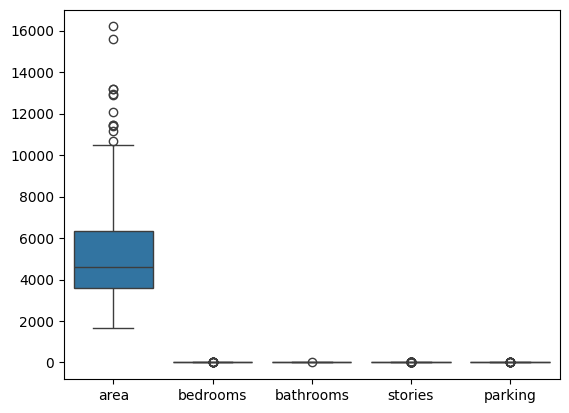

In [8]:
sns.boxplot(x[num_cols])

In [9]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y, train_size=0.8, random_state=42)

In [11]:
scaling = RobustScaler()
xtrain[num_cols] = scaling.fit_transform(xtrain[num_cols])
xtrain


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,0.543478,0.0,1.0,2.0,yes,no,no,no,yes,1.0,no,furnished
93,0.978261,0.0,1.0,-1.0,yes,no,yes,no,yes,3.0,no,semi-furnished
335,-0.247826,-1.0,0.0,-1.0,yes,no,yes,no,yes,2.0,no,furnished
412,-0.684783,0.0,0.0,0.0,yes,no,yes,no,no,0.0,yes,unfurnished
471,-0.271739,0.0,0.0,0.0,yes,no,no,no,no,0.0,no,unfurnished
...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.543478,1.0,1.0,2.0,yes,no,no,no,yes,0.0,no,unfurnished
106,0.344203,1.0,1.0,-1.0,yes,no,yes,no,yes,0.0,yes,semi-furnished
270,0.000000,0.0,1.0,1.0,yes,no,no,yes,no,1.0,no,furnished
435,-0.166667,-1.0,0.0,-1.0,yes,no,no,no,no,0.0,no,unfurnished


In [13]:
# sns.boxplot(xtrain[num_cols])

In [14]:
df.select_dtypes(include='number').corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


In [15]:
xtrain[obj_cols].nunique()

mainroad            2
guestroom           2
basement            2
hotwaterheating     2
airconditioning     2
prefarea            2
furnishingstatus    3
dtype: int64

In [16]:
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
values = onehot_encoder.fit_transform(xtrain[obj_cols])
cols = onehot_encoder.get_feature_names_out()

In [17]:
xtrain[cols] = values
xtrain.drop(columns = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus'],inplace= True)
xtrain

,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,basement_no,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,0.543478,0.0,1.0,2.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
93,0.978261,0.0,1.0,-1.0,3.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
335,-0.247826,-1.0,0.0,-1.0,2.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
412,-0.684783,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
471,-0.271739,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.543478,1.0,1.0,2.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
106,0.344203,1.0,1.0,-1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
270,0.000000,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
435,-0.166667,-1.0,0.0,-1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [20]:
xtest[num_cols] = scaling.transform(xtest[num_cols])
xtest_values = onehot_encoder.transform(xtest[obj_cols])
xtest[cols] = xtest_values
xtest.drop(columns = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus'], inplace=True)
xtest

,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,basement_no,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,-1.631025,-5.0,-1.0,-4.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
77,-1.631025,-6.0,-1.0,-3.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
360,-1.631026,-7.0,-2.0,-5.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
90,-1.631025,-6.0,-2.0,-4.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
493,-1.631026,-6.0,-2.0,-5.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,-1.631025,-5.0,-2.0,-4.0,2.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
357,-1.631025,-5.0,-2.0,-4.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
39,-1.631025,-5.0,-1.0,-2.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
54,-1.631025,-6.0,-1.0,-4.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [22]:
model = LinearRegression()
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
model.score(xtrain,ytrain)

0.6859438988560158

In [24]:
model.score(xtest,ytest)

-5.725725083701009